# Линейная регрессия, обучение и валидация модели.

### Одномерная линейная регрессия

1. Выведите формулу обновления весов одномерной линейной регрессии методом градиентного спуска.

2. Напишите функцию, релизующую обучение одномерной линейной регрессии методом градиентного спуска.

In [1]:
def linear_regression(X, y_true, m = 0, b = 0, epochs = 1000, learning_rate = 0.0001) :
    N = float(len(y_true))
    for i in range(epochs):
        y_pred = m * X + b
        cost = sum([err**2 for err in (y_pred - y_true)])*(1./N)
        m_gradient = (2./N)*sum(X*(y_pred-y_true))
        b_gradient = (2./N)*sum(y_pred-y_true)
        m = m - learning_rate * m_gradient
        b = b - learning_rate * b_gradient   
    return m, b, cost

## Сгенерируем точки для задачи регрессии

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/Users/underlord/projects/machine_learning_msu/.venv/lib/python3.12/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random', 'plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


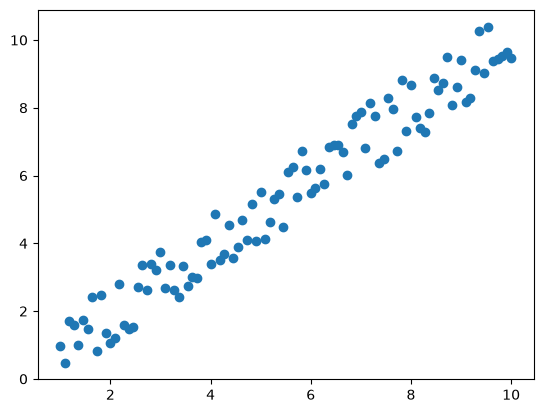

In [ ]:
import random
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
import seaborn as sns
plt.style.use('ggplot')
%pylab inline

num_points = 100
m, b, delta = 1, 0, 1

x = np.linspace(1, 10, num_points)
y = m * x + b + random.uniform(-delta, delta, num_points)

plt.scatter(x,y)

### Обучим нашу линейную регрессию и посмотрим на результат

MSE: 0.3872360689243953


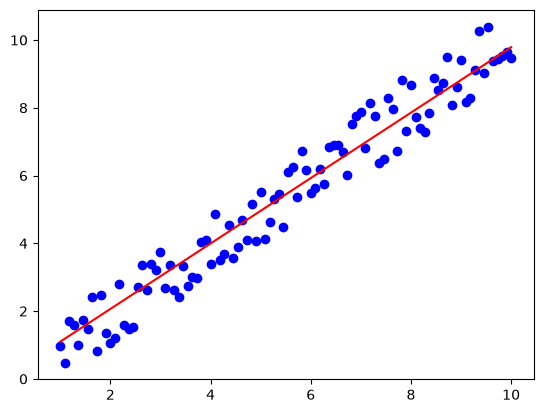

In [3]:
m, b, cost = linear_regression(x, y) # обучение

y_pred = m * x + b # предсказание

plt.scatter(x, y, color = 'blue')
plt.plot(x, y_pred, 'r-')

print('MSE: {}'.format(cost))

# Задание 1

Поэкспериментируйте с количеством шагов (epochs) и learning rate.
Как меняется итоговая ошибка при фиксированном числе шагов и различных learning rate?

1) Постройте графики для learning rate = 0.1, 0.01, 0.0001 и epochs = 10, 100, 1000 (всего 9 графиков).
Рядом с каждым графиком выведите ошибку (cost).

2) Прокомментируйте каждый график: ответьте на вопрос, почему вы видите именно такую прямую?

In [4]:
linear_regression(x, y, learning_rate = 0.1, epochs = 10) # обучение

(np.float64(-149210391.22556168),
 np.float64(-22206974.60767425),
 np.float64(1.988292928943399e+16))

In [5]:
linear_regression(x, y, learning_rate = 0.0001, epochs = 10) # обучение

(np.float64(0.07077936485163505),
 np.float64(0.010421136873076461),
 np.float64(31.85187089159477))

lr =  0.1
ep =  10
MSE: 0.3872360689243953


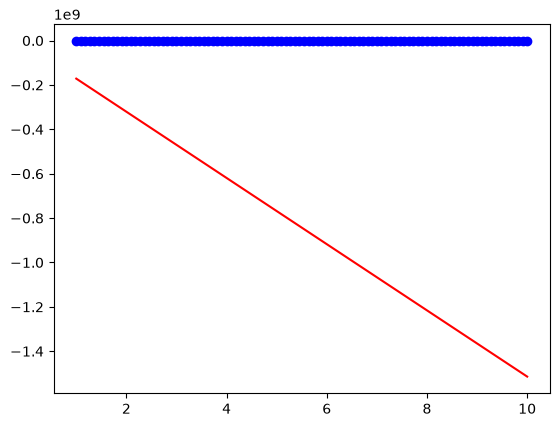

lr =  0.1
ep =  100
MSE: 1.988292928943399e+16


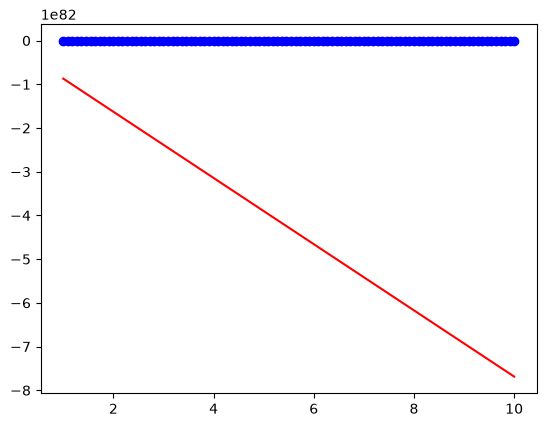

lr =  0.1
ep =  1000
MSE: 5.123260981515151e+163


/var/folders/kh/shll5vkj0_7ff7_ktf3vqsxc0000gn/T/ipykernel_74849/4017188769.py:5: RuntimeWarning: overflow encountered in scalar power
  cost = sum([err**2 for err in (y_pred - y_true)])*(1./N)
/Users/underlord/projects/machine_learning_msu/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/kh/shll5vkj0_7ff7_ktf3vqsxc0000gn/T/ipykernel_74849/4017188769.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - learning_rate * m_gradient


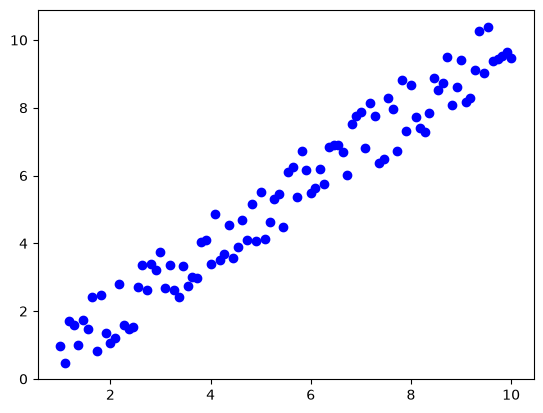

lr =  0.01
ep =  10
MSE: nan


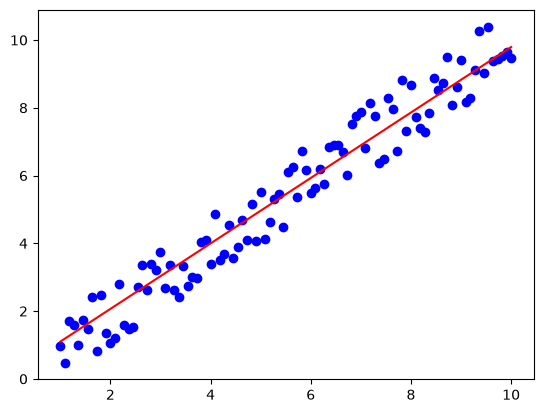

lr =  0.01
ep =  100
MSE: 0.3873407360494738


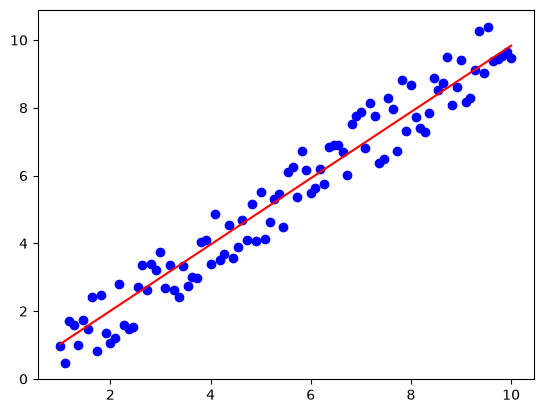

lr =  0.01
ep =  1000
MSE: 0.37960219396724126


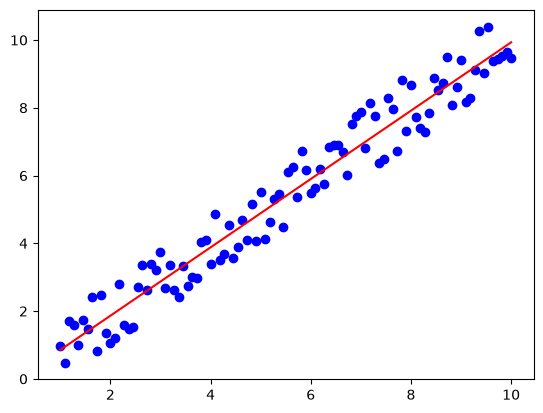

lr =  0.0001
ep =  10
MSE: 0.37123830942738684


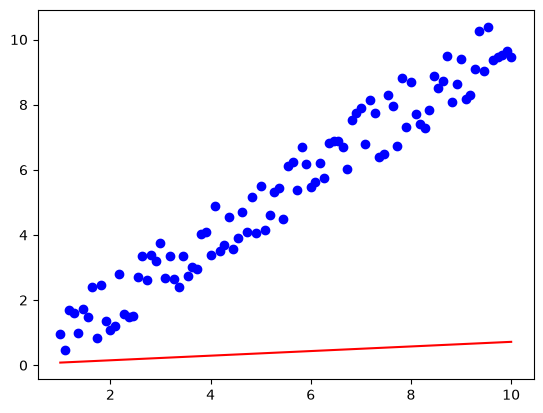

lr =  0.0001
ep =  100
MSE: 31.85187089159477


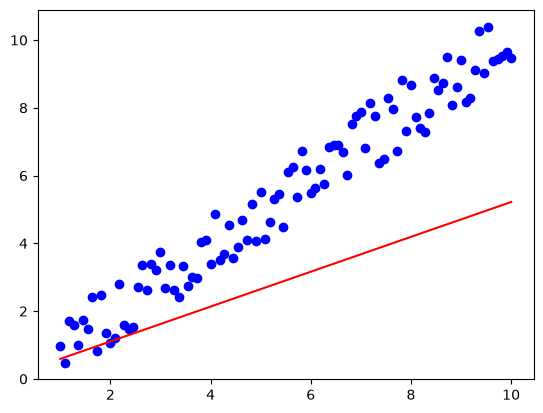

lr =  0.0001
ep =  1000
MSE: 8.370688119060196


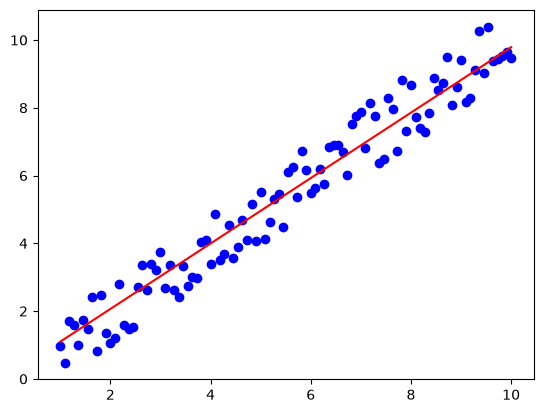

In [6]:
for lr in [0.1, 0.01, 0.0001] :
    for ep in [10, 100, 1000]  :
        print('lr = ', lr)
        print('ep = ', ep)
        print('MSE: {}'.format(cost))  
        m, b, cost = linear_regression(x, y, learning_rate = lr, epochs = ep) # обучение
        y_pred = m * x + b # предсказание
        plt.scatter(x, y, color = 'blue')
        plt.plot(x, y_pred, 'r-')
        plt.show()     

# Задание 2

Подумайте, как применить написанную функцию линейной регрессии для аппроксимации следующего набора точек. Решите эту задачу. Выведите на экран итоговое приближение (график) и ошибку.

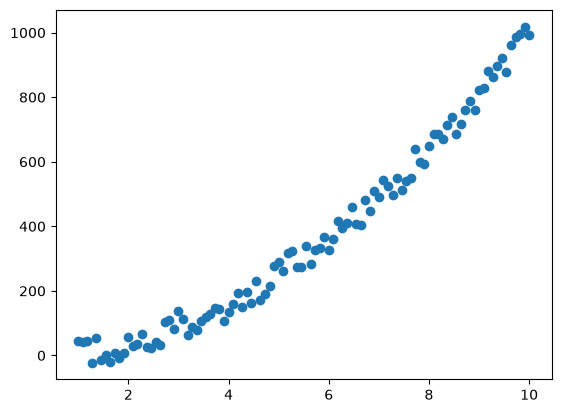

In [7]:
num_points = 100
m, b, delta = 10, 0, 50

x = np.linspace(1, 10, num_points)
y = m * x**2 + b + random.uniform(-delta, delta, num_points)

plt.scatter(x,y)

MSE: 772.540401104021


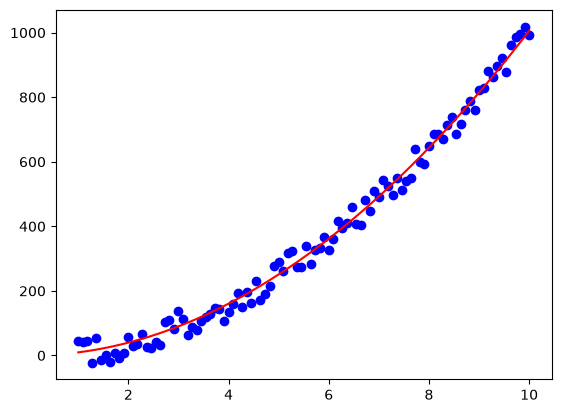

In [8]:
x2 = x ** 2

m, b, cost = linear_regression(x2, y) # обучение

y_pred = m * x2 + b # предсказание

plt.scatter(x, y, color='blue')
plt.plot(x, y_pred, 'r-')

print('MSE: {}'.format(cost))

In [9]:
from sklearn.metrics import r2_score

r2_score(y, y_pred)

0.9915400463947944

# Задание 3

Считайте файл weights_heights.csv

In [10]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/hdrbv/machine_learning_msu/'
    'c14655b3393ba1ff746dd6c2ca5c326c12874631/'
    '2026-fall/week_2/seminar_HB/weights_heights.csv'
)
df.head()

,Weight,Height
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Height", y="Weight", alpha=0.5)
plt.title("Связь роста и веса")
plt.xlabel("Рост")
plt.ylabel("Вес")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Height", y="Weight",
            scatter_kws={"alpha": 0.4},
            line_kws={"color": "blue"})
plt.title("Рост и вес: линейная регрессия")
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Height"], bins=30, kde=True)
plt.title("Распределение роста")
plt.xlabel("Рост")
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Weight"], bins=30, kde=True)
plt.title("Распределение веса")
plt.xlabel("Вес")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["Height"], ax=axes[0])
axes[0].set_title("Выбросы роста")

sns.boxplot(y=df["Weight"], ax=axes[1])
axes[1].set_title("Выбросы веса")

plt.show()

In [ ]:
sns.jointplot(data=df, x="Height", y="Weight", kind="reg")
plt.show()

In [ ]:
sns.pairplot(
    df[["Height", "Weight"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.4}
)
plt.show()

In [ ]:
sns.heatmap(
    df[["Height", "Weight"]].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
plt.title("Корреляция признаков")
plt.show()

### Обучение и валидация модели.

Разобъем данные на обучающую и тестовую часть и обучим линейную регрессию на обучающей выборке (используйте функцию linear_regression для обучения)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of array-like of shape (n_samples,) or             (n_samples, n_outputs)
        Indexable data-structures can be arrays, lists, dataframes, scipy
        sparse matrices or pandas dataframes with consistent first dimension.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df['Height'], df['Weight'], test_size = 0.2)

m, b, cost = linear_regression(X_train, y_train, learning_rate = 0.00001)

Сделаем предсказание на обучающей и тестовой выборках по формуле y = mx+b.

Вычислим RMSE на train и на test.

In [14]:
from sklearn.metrics import mean_squared_error

pred_train = m * X_train + b
pred_test = m * X_test + b

print("Train RMSE: {}".format(np.sqrt(mean_squared_error(y_train, pred_train))))
print("Test RMSE: {}".format(np.sqrt(mean_squared_error(y_test, pred_test))))

Train RMSE: 5.510408826127801
Test RMSE: 5.510096812215543


# Теперь проверим, как работает функция линейной регрессии из sklearn

In [15]:
X_train.head()

5792     130.0904
16212    137.5848
18434    133.6540
17994    126.9513
3012     121.6422
Name: Height, dtype: float64

In [16]:
from sklearn.linear_model import LinearRegression

X_train2, X_test2, y_train, y_test = train_test_split(df[['Height']], df['Weight'], test_size = 0.2)

lr = LinearRegression()
lr.fit(X_train2, y_train)

pred_train = lr.predict(X_train2)
pred_test = lr.predict(X_test2)

print("Train RMSE: {}".format(np.sqrt(mean_squared_error(y_train, pred_train))))
print("Test RMSE: {}".format(np.sqrt(mean_squared_error(y_test, pred_test))))

Train RMSE: 1.6397756934093248
Test RMSE: 1.6594138235073361


In [17]:
help(LinearRegression())

Help on LinearRegression in module sklearn.linear_model._base object:

class LinearRegression(sklearn.base.RegressorMixin, MultiOutputLinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, tol=1e-06, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  tol : float, default=1e-6
 |      The precision of the solution (`coef_`) is determined by `tol` which
 |      specifies the co

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Регрессия---моя-профессия" data-toc-modified-id="Регрессия---моя-профессия-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Регрессия - моя профессия</a></span><ul class="toc-item"><li><span><a href="#Данные" data-toc-modified-id="Данные-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Данные</a></span></li><li><span><a href="#Вопросы" data-toc-modified-id="Вопросы-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Вопросы</a></span></li></ul></li><li><span><a href="#Парная-регрессия-в-уровнях" data-toc-modified-id="Парная-регрессия-в-уровнях-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Парная регрессия в уровнях</a></span></li><li><span><a href="#Парная-регрессия-в-логарифмах" data-toc-modified-id="Парная-регрессия-в-логарифмах-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Парная регрессия в логарифмах</a></span></li><li><span><a href="#Множественная-регрессия" data-toc-modified-id="Множественная-регрессия-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Множественная регрессия</a></span></li><li><span><a href="#Проверка-предпосылок-модели" data-toc-modified-id="Проверка-предпосылок-модели-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Проверка предпосылок модели</a></span><ul class="toc-item"><li><span><a href="#Выводы" data-toc-modified-id="Выводы-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Логистическая регрессия</a></span></li></ul></div>

In [18]:
import numpy as np
import pandas as pd
import statsmodels as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')
%matplotlib inline

In [19]:
X = stats.uniform().rvs(size = 100) + stats.expon(1).rvs(size = 100)

In [20]:
help(stats.expon)

Help on expon_gen in module scipy.stats._continuous_distns:

<scipy.stats._continuous_distns.expon_gen object>
    An exponential continuous random variable.

    As an instance of the `rv_continuous` class, `expon` object inherits from it
    a collection of generic methods (see below for the full list),
    and completes them with details specific for this particular distribution.

    Methods
    -------
    rvs(loc=0, scale=1, size=1, random_state=None)
        Random variates.
    pdf(x, loc=0, scale=1)
        Probability density function.
    logpdf(x, loc=0, scale=1)
        Log of the probability density function.
    cdf(x, loc=0, scale=1)
        Cumulative distribution function.
    logcdf(x, loc=0, scale=1)
        Log of the cumulative distribution function.
    sf(x, loc=0, scale=1)
        Survival function  (also defined as ``1 - cdf``, but `sf` is sometimes more accurate).
    logsf(x, loc=0, scale=1)
        Log of the survival function.
    ppf(q, loc=0, scale=1)
  

In [21]:
X

array([3.06570316, 2.57288752, 1.76376546, 2.17638553, 1.67139131,
       2.35159989, 2.36340417, 3.30787328, 1.94976166, 6.20071992,
       3.14540727, 1.93460961, 2.09665955, 1.88964761, 1.39796479,
       3.05882291, 3.08160738, 1.15211699, 2.52006799, 1.99498603,
       3.47163092, 2.24874708, 1.96176122, 2.03920151, 2.7012011 ,
       1.61244661, 1.20281712, 1.34954608, 1.38960181, 2.27730672,
       1.8920062 , 2.6012848 , 2.33085306, 1.62821723, 2.16904415,
       1.840424  , 2.47130433, 2.39800276, 2.34754082, 2.0376044 ,
       2.81721291, 2.58974296, 2.17927267, 3.92883219, 2.0615069 ,
       1.58582964, 3.15026477, 2.97347081, 1.75528951, 2.87730563,
       2.39722874, 2.16973255, 2.20281487, 2.53803757, 1.70562831,
       2.94668769, 1.35634337, 1.43755279, 1.31795353, 3.04614064,
       2.26648719, 1.45531148, 1.6534337 , 1.84241842, 2.66231945,
       2.96220281, 3.27260938, 1.61299463, 2.73479376, 2.4456529 ,
       1.12784252, 2.7087553 , 1.99109204, 2.67480297, 2.65096

In [22]:
X.shape

(100,)

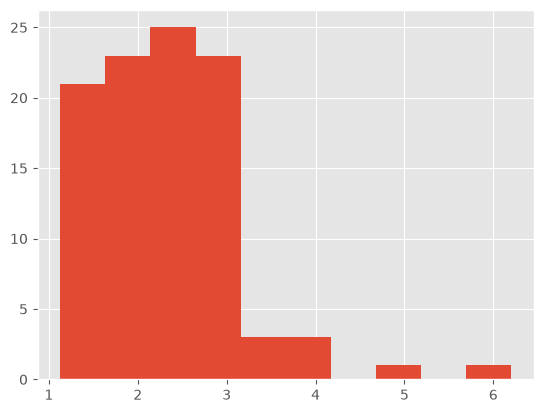

In [23]:
plt.hist(X);

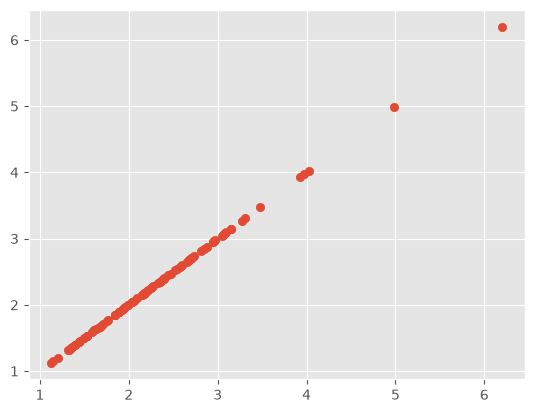

In [24]:
Y = X
plt.scatter(X, Y);

In [25]:
stats.pearsonr(X, Y)

PearsonRResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))

In [26]:
Y_right = X + 0.1 * stats.norm().rvs(size = len(X))

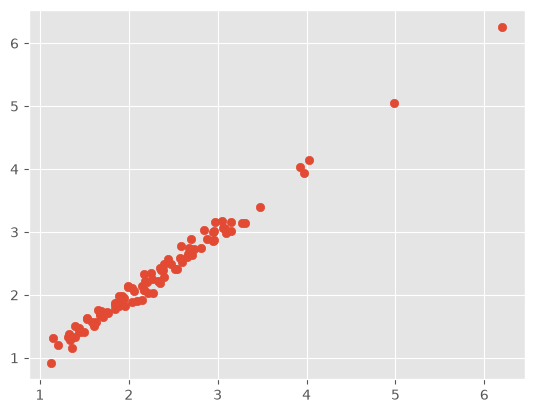

In [27]:
plt.scatter(X, Y_right);

In [28]:
stats.pearsonr(X, Y_right)

PearsonRResult(statistic=np.float64(0.9929191125627069), pvalue=np.float64(1.7279609038903076e-92))

#  Регрессия

В этой тетрадке мы попробуем найти оценки и проверить пару гипотез. 

## Данные

In [29]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/hdrbv/machine_learning_msu/'
    'c14655b3393ba1ff746dd6c2ca5c326c12874631/'
    '2026-fall/week_2/seminar_HB/Advertising.csv',
    index_col=0,
)
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


__Описание колонок:__ 

- `Sales` - продажи продукта на данном рынке (в тысячах штук) 
- `TV` -  доллары, потраченные на ТВ рекламу для одного продукта на данном рынке (в тысячах долларов)
- `Radio` - доллары, потраченные на радио рекламу
- `Newspaper` - доллары, потраченные на рекламу в газетах

В нашей выборке мы имеем 200 **наблюдений** (200 разных рынков с разным объёмом рекламы)

## Вопросы

Давайте представим, что мы работаем на компанию, которая производит и продает этот товар. Компания может задать нам вопрос: как мы должны тратить наши рекламные деньги в будущем?

Этот общий вопрос может привести вас к более конкретным вопросам:

1. Существует ли связь между рекламой и продажами?
2. Насколько сильны эти отношения?
3. Какие типы рекламы способствуют росту продаж?
4. Зная расходы на рекламу на конкретном рынке, можем ли мы предсказать продажи?

# Парная регрессия в уровнях

Взглянем как продажи зависят от типов рекламы.

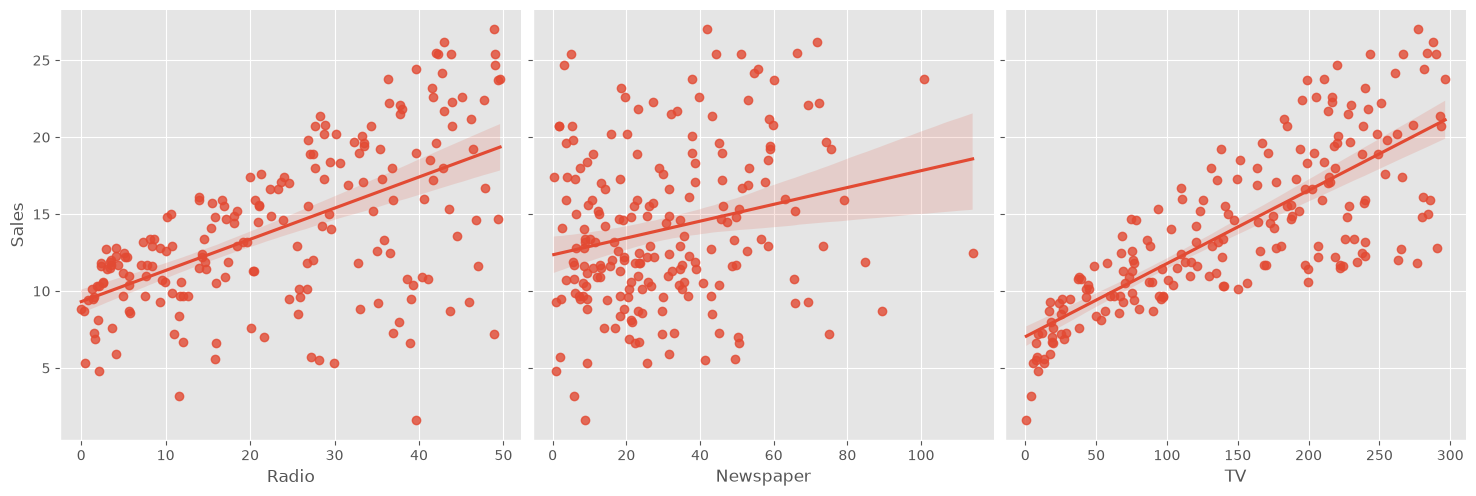

In [30]:
sns.pairplot(
    df, 
    y_vars = 'Sales', 
    x_vars = ['Radio', 'Newspaper', 'TV'], 
    height = 5,
    kind = 'reg',
    diag_kind = None
);

In [31]:
df.corr()['Sales']

TV           0.782224
Radio        0.576223
Newspaper    0.228299
Sales        1.000000
Name: Sales, dtype: float64

Для начала давайте поговорим только про рекламу на TV. Оценим параметры модели 

$$
Sales_i = \beta_1 + \beta_2 \cdot TV_i + \varepsilon_i
$$

In [32]:
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [33]:
import statsmodels.formula.api as smf

model = smf.ols('Sales ~ TV', data = df)
res = model.fit() #.fit_regularized()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           1.47e-42
Time:                        10:39:22   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.0

In [34]:
res.params

Intercept    7.032594
TV           0.047537
dtype: float64

- p_value < 0.05 -> $H_0: \beta = 0$ -> отвергается - коэффициент значим, коэффициент НЕ равен 0
- p_value > 0.05 -> $H_0: \beta = 0$ -> НЕ отвергается - коэффициент НЕ значим, коэффициент равен 0

- Переменная $TV$ значима, так как $p$-значение для проверки гипотезы о том, что она равна нулю оказалось очень маленьким, наблюдаемое значение статистики $17.668$. Оно лежит глубоко в хвосте нашего распределения. 
- Получившееся уравнение 

$$
Sales_i = 7.033 + 0.047 \cdot TV_i
$$

можно проинтерпретировать так, что каждые дополнительные $1000$ долларов, потраченные на рекламу по телевизору, увеличивают продажи на $47.537$ товаров.

> Мы можем так интерпретировать значение коэффициента, если выполняются предпосылки линейной регрессии. Например, первая предпослыка говорит о том, что мы должны были верно специфицировать модель. 

Если модель специфицирована неверно, у нас есть проблемы. 

> Мы получаем корректные оценки стандартных ошибок в ситуации, когда ошибки независимо одинаково распределены с одинаковой дисперсией. Если это не так, оценки ошибок искажены. 

- Информационные критерии
    - [Akaike information criterion](https://en.wikipedia.org/wiki/Akaike_information_criterion):
    $\mathrm{AIC} \, = \, 2k - 2\ln(\hat L)$
    - [Bayesian information criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion):
    $\mathrm{BIC} = k\ln(n) - 2\ln(\widehat L)$
- Коэффициенты детерминации
    - $ R^2 = 1-{RSS \over TSS}$
    - $ R^2_\text{adj} = 1-{RSS/(n-k-1) \over TSS/(n-1)}$